# 02 — Preprocessing

Based on the audit in notebook 01, this notebook: drops the handful of rows with a missing target, imputes missing features, treats outliers/skew, encodes the categorical variable, and saves a clean dataset to `data/processed/`. Every step reports before/after evidence.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.insert(0, '../src')
from utils import load_raw

sns.set_style('whitegrid')
df = load_raw()
print('Starting shape:', df.shape)

Starting shape: (2938, 22)


## Step 1 — Drop rows with missing target
We can't train or evaluate on a row with no `life_expectancy` value, and there's no principled way to impute the thing we're trying to predict. Only 10 rows are affected.

In [2]:
before = len(df)
df = df.dropna(subset=['life_expectancy']).reset_index(drop=True)
print(f'Dropped {before - len(df)} rows with missing target. New shape: {df.shape}')

Dropped 10 rows with missing target. New shape: (2928, 22)


## Step 2 — Missing value imputation
The audit showed missingness is **structural, not random** — it clusters by country (some countries just don't report certain indicators consistently). A single global mean/median would blur real cross-country differences. So we impute in three passes, each only filling what the previous pass couldn't:

1. **Within-country linear interpolation across years** — if France is missing GDP for 2003 but has 2002 and 2004, interpolate between them.
2. **Within-country forward/backward fill** — for edge years interpolation can't reach (e.g. missing at the first or last year on record).
3. **Group median by `status` (Developed/Developing)** — for countries missing a feature in *every* year, fall back to the median for their development-status peer group, which is far less biased than a single global median.

In [3]:
missing_before = df.isnull().sum()
missing_before = missing_before[missing_before > 0]
print('Missing values BEFORE imputation:')
print(missing_before)

Missing values BEFORE imputation:
alcohol                 193
hepatitis_b             553
bmi                      32
polio                    19
total_expenditure       226
diphtheria               19
gdp                     443
population              644
thinness_10_19_years     32
thinness_5_9_years       32
income_composition      160
schooling               160
dtype: int64


In [4]:
numeric_cols_to_impute = missing_before.index.tolist()

df = df.sort_values(['country', 'year']).reset_index(drop=True)

# Pass 1 + 2: within-country interpolation, then ffill/bfill for edges
# (include_groups=False in newer pandas drops the 'country' column from the group passed to
# the function AND from the result, so we re-attach it afterward using the preserved index)
country_col = df['country'].copy()
def impute_within_country(group):
    group[numeric_cols_to_impute] = group[numeric_cols_to_impute].interpolate(
        method='linear', limit_direction='both')
    return group

df = df.groupby('country', group_keys=False)[df.columns.drop('country')].apply(impute_within_country)
df['country'] = country_col

# Pass 3: for countries missing a feature in EVERY year, fall back to status-group median
for col in numeric_cols_to_impute:
    df[col] = df.groupby('status')[col].transform(lambda s: s.fillna(s.median()))

missing_after = df.isnull().sum()
missing_after = missing_after[missing_after > 0]
print('Missing values AFTER imputation:')
print(missing_after if len(missing_after) else 'None remaining.')

Missing values AFTER imputation:
None remaining.


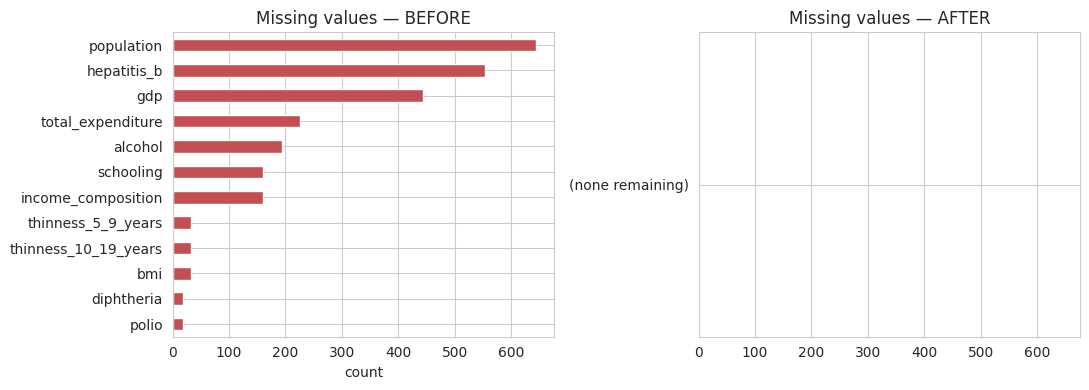

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
missing_before.sort_values().plot(kind='barh', ax=axes[0], color='#C44E52')
axes[0].set_title('Missing values — BEFORE')
axes[0].set_xlabel('count')
pd.Series([0], index=['(none remaining)']).plot(kind='barh', ax=axes[1], color='#55A868')
axes[1].set_title('Missing values — AFTER')
axes[1].set_xlim(axes[0].get_xlim())
plt.tight_layout()
plt.savefig('../figures/05_missing_before_after.png', dpi=120)
plt.show()

## Step 3 — Outliers
**Low `life_expectancy` outliers (Haiti 2010, Malawi/Sierra Leone/Zimbabwe early-2000s):** verified against real-world events (2010 Haiti earthquake; HIV/AIDS epidemic peak in southern Africa). These are **kept** — they're real signal the model should learn from, not noise.

**Heavily right-skewed count/monetary features** (`measles`, `infant_deaths`, `under_five_deaths`, `population`, `gdp`, `percentage_expenditure`): these aren't errors either, but their raw scale (a few extreme countries dwarfing everyone else) will destabilize linear models and distort distance-based feature selection. We apply a `log1p` transform (handles the zeros safely) rather than deleting or capping any data.

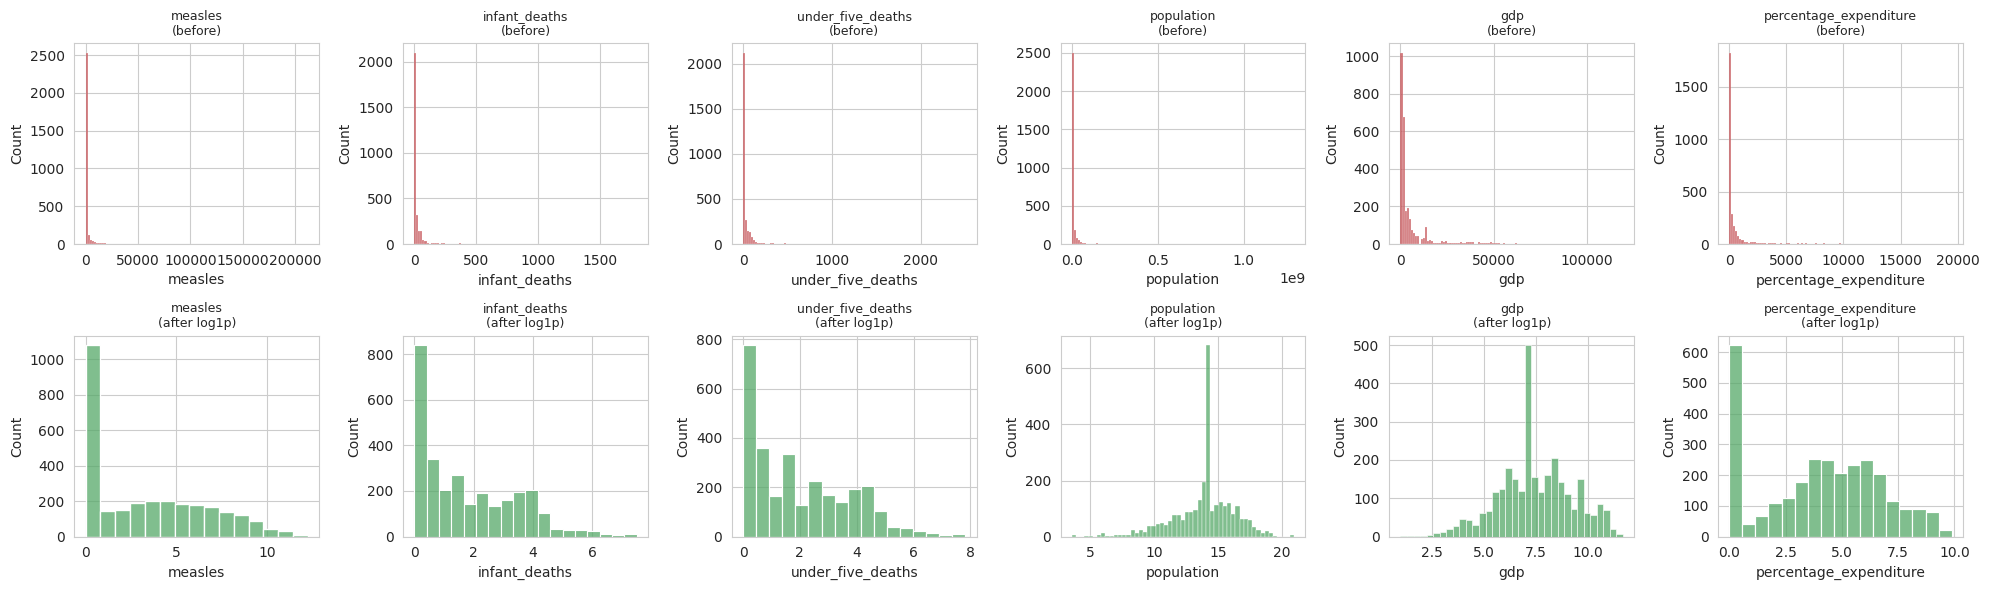

Applied log1p to: ['measles', 'infant_deaths', 'under_five_deaths', 'population', 'gdp', 'percentage_expenditure']


In [6]:
skewed_cols = ['measles', 'infant_deaths', 'under_five_deaths', 'population', 'gdp', 'percentage_expenditure']

fig, axes = plt.subplots(2, len(skewed_cols), figsize=(20, 6))
for i, col in enumerate(skewed_cols):
    sns.histplot(df[col], ax=axes[0, i], color='#C44E52')
    axes[0, i].set_title(f'{col}\n(before)', fontsize=9)
    log_vals = np.log1p(df[col])
    sns.histplot(log_vals, ax=axes[1, i], color='#55A868')
    axes[1, i].set_title(f'{col}\n(after log1p)', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/06_skew_before_after.png', dpi=120)
plt.show()

for col in skewed_cols:
    df[col] = np.log1p(df[col])
print('Applied log1p to:', skewed_cols)

## Step 4 — Encode the categorical variable
`status` has only two values (Developed / Developing), so we one-hot/binary encode it rather than pulling in a full encoder for a single binary column.

In [7]:
df['status_developed'] = (df['status'] == 'Developed').astype(int)
print(df[['status', 'status_developed']].drop_duplicates())

         status  status_developed
0    Developing                 0
112   Developed                 1


## Step 5 — Scaling (demonstrated here, applied inside modeling pipelines)
We show the effect of `StandardScaler` here for evidence, but the **actual** scaling used for modeling is fit inside each cross-validation fold in notebook 04 (not on the whole dataset up front) — fitting a scaler on the full dataset before splitting would leak test-set statistics into training, which is a common mistake we're deliberately avoiding.

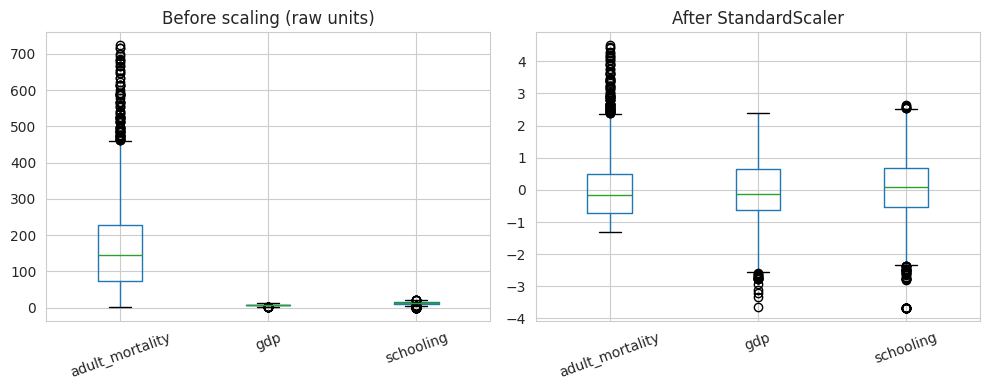

In [8]:
from sklearn.preprocessing import StandardScaler

demo_cols = ['adult_mortality', 'gdp', 'schooling']
scaler_demo = StandardScaler()
scaled_demo = pd.DataFrame(scaler_demo.fit_transform(df[demo_cols]), columns=demo_cols)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df[demo_cols].boxplot(ax=axes[0])
axes[0].set_title('Before scaling (raw units)')
axes[0].tick_params(axis='x', rotation=20)
scaled_demo.boxplot(ax=axes[1])
axes[1].set_title('After StandardScaler')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('../figures/07_scaling_demo.png', dpi=120)
plt.show()

## Save the cleaned dataset

In [9]:
df = df.drop(columns=['status'])  # replaced by status_developed
print('Final shape:', df.shape)
print('Remaining missing values:', df.isnull().sum().sum())
df.to_csv('../data/processed/life_expectancy_clean.csv', index=False)
print('Saved to data/processed/life_expectancy_clean.csv')

Final shape: (2928, 22)
Remaining missing values: 0
Saved to data/processed/life_expectancy_clean.csv


## Summary of what changed
| Step | Action | Rows/cols affected |
|---|---|---|
| Target missing | Dropped rows | 10 rows |
| Feature missing | Within-country interpolation → ffill/bfill → status-group median | 8 columns, up to 34% missing each |
| Low life expectancy outliers | Verified as real events, kept | 19 rows |
| Skewed count/monetary features | `log1p` transform | 6 columns |
| `status` | Encoded to `status_developed` (0/1) | 1 column |
| Scaling | Deferred to per-fold pipeline (avoids leakage) | — |